In [9]:
!pip install yfinance

In [10]:
import yfinance as yf
import pandas as pd
import datetime
import matplotlib.pyplot as plt
import numpy as np

### Extract Yahoo finance data

In [11]:
# Define the currency pair
pair = "USDZAR=X"  # USD to South African Rand

# Download historical data (last 24 month, daily)
data = yf.download(pair, period="120mo", interval="1d")

# Convert to Pandas DataFrame
forex_df = pd.DataFrame(data)

# Inspect the first few row
forex_df


C:\Users\Mathiane karabo\AppData\Local\Temp\ipykernel_25016\3560607890.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(pair, period="120mo", interval="1d")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,USDZAR=X,USDZAR=X,USDZAR=X,USDZAR=X,USDZAR=X
Date,,,,,
2015-09-28,13.861880,14.062030,13.799900,13.861880,0
2015-09-29,14.057400,14.153300,13.887780,14.056620,0
2015-09-30,13.968380,13.968280,13.790500,13.968280,0
2015-10-01,13.825780,13.869980,13.719000,13.824970,0
2015-10-02,13.919280,14.016290,13.750480,13.918880,0
...,...,...,...,...,...
2025-09-23,17.330900,17.381300,17.228701,17.330900,0
2025-09-24,17.228100,17.344999,17.207001,17.228100,0


In [12]:
forex_df = forex_df[['Close']]
forex_df.index

DatetimeIndex(['2015-09-28', '2015-09-29', '2015-09-30', '2015-10-01',
               '2015-10-02', '2015-10-05', '2015-10-06', '2015-10-07',
               '2015-10-08', '2015-10-09',
               ...
               '2025-09-16', '2025-09-17', '2025-09-18', '2025-09-19',
               '2025-09-22', '2025-09-23', '2025-09-24', '2025-09-25',
               '2025-09-26', '2025-09-27'],
              dtype='datetime64[ns]', name='Date', length=2605, freq=None)

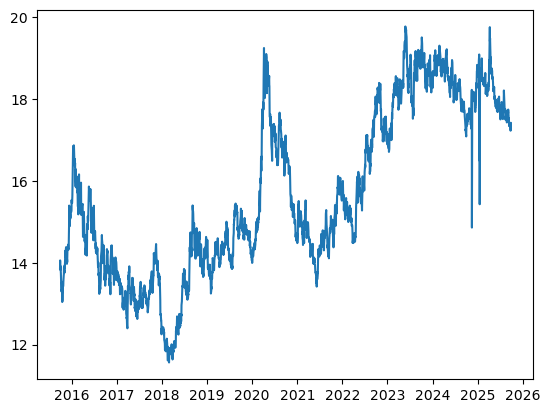

In [13]:
plt.plot(forex_df.index, forex_df['Close'])

### Convert to supervised learning problem

In [14]:
def df_to_windowed_df(dataframe, first_date_str, last_date_str, n=3):
  first_date = pd.to_datetime(first_date_str)
  last_date  = pd.to_datetime(last_date_str)

  target_date = first_date
  
  dates = []
  X, Y = [], []

  last_time = False
  while True:
    df_subset = dataframe.loc[:target_date].tail(n+1)
    
    if len(df_subset) != n+1:
      print(f'Error: Window of size {n} is too large for date {target_date}')
      return

    values = df_subset['Close'].to_numpy()
    x, y = values[:-1], values[-1]

    dates.append(target_date)
    X.append(x)
    Y.append(y)

    next_week = dataframe.loc[target_date:target_date+datetime.timedelta(days=7)]
    next_datetime_str = str(next_week.head(2).tail(1).index.values[0])
    next_date_str = next_datetime_str.split('T')[0]
    year_month_day = next_date_str.split('-')
    year, month, day = year_month_day
    next_date = datetime.datetime(day=int(day), month=int(month), year=int(year))
    
    if last_time:
      break
    
    target_date = next_date

    if target_date == last_date:
      last_time = True
    
  ret_df = pd.DataFrame({})
  ret_df['Target Date'] = dates
  
  X = np.array(X)
  for i in range(0, n):
    X[:, i]
    ret_df[f'Target-{n-i}'] = X[:, i]
  
  ret_df['Target'] = Y

  return ret_df

# Start day second time around: '2021-03-25'
windowed_df = df_to_windowed_df(forex_df, '2021-03-25', '2022-03-23', n=3)
windowed_df

,Target Date,Target-3,Target-2,Target-1,Target
0,2021-03-25,14.81163,14.70250,14.88120,[14.950360298156738]
1,2021-03-26,14.70250,14.88120,14.95036,[14.995719909667969]
2,2021-03-29,14.88120,14.95036,14.99572,[14.971949577331543]
3,2021-03-30,14.95036,14.99572,14.97195,[14.910730361938477]
4,2021-03-31,14.99572,14.97195,14.91073,[14.901180267333984]
...,...,...,...,...,...
255,2022-03-17,15.00000,15.09295,15.08740,[14.906200408935547]
256,2022-03-18,15.09295,15.08740,14.90620,[14.904399871826172]
257,2022-03-21,15.08740,14.90620,14.90440,[14.922430038452148]
258,2022-03-22,14.90620,14.90440,14.92243,[14.898750305175781]


In [15]:
def windowed_df_to_date_X_y(windowed_dataframe):
  df_as_np = windowed_dataframe.to_numpy()

  dates = df_as_np[:, 0]

  middle_matrix = df_as_np[:, 1:-1]
  X = middle_matrix.reshape((len(dates), middle_matrix.shape[1], 1))

  Y = df_as_np[:, -1]

  return dates, X.astype(np.float32), Y.astype(np.float32)

dates, X, y = windowed_df_to_date_X_y(windowed_df)

dates.shape, X.shape, y.shape

C:\Users\Mathiane karabo\AppData\Local\Temp\ipykernel_25016\3836700885.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return dates, X.astype(np.float32), Y.astype(np.float32)


((260,), (260, 3, 1), (260,))

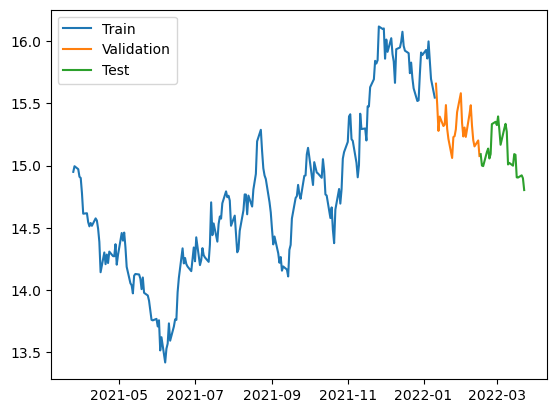

In [16]:
q_80 = int(len(dates) * .8)
q_90 = int(len(dates) * .9)

dates_train, X_train, y_train = dates[:q_80], X[:q_80], y[:q_80]

dates_val, X_val, y_val = dates[q_80:q_90], X[q_80:q_90], y[q_80:q_90]
dates_test, X_test, y_test = dates[q_90:], X[q_90:], y[q_90:]

plt.plot(dates_train, y_train)
plt.plot(dates_val, y_val)
plt.plot(dates_test, y_test)

plt.legend(['Train', 'Validation', 'Test'])

In [ ]:
!pip install tensorflow

In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers

model = Sequential([layers.Input((3, 1)),
                    layers.LSTM(64),
                    layers.Dense(32, activation='relu'),
                    layers.Dense(32, activation='relu'),
                    layers.Dense(1)])

model.compile(loss='mse', 
              optimizer=Adam(learning_rate=0.001),
              metrics=['mean_absolute_error'])

model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=100)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 120ms/step - loss: 215.2022 - mean_absolute_error: 14.6545 - val_loss: 225.6091 - val_mean_absolute_error: 15.0196
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 205.4386 - mean_absolute_error: 14.3177 - val_loss: 215.1070 - val_mean_absolute_error: 14.6658
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 194.2071 - mean_absolute_error: 13.9198 - val_loss: 201.1257 - val_mean_absolute_error: 14.1812
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 179.0185 - mean_absolute_error: 13.3625 - val_loss: 182.5023 - val_mean_absolute_error: 13.5086
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 159.0392 - mean_absolute_error: 12.5941 - val_loss: 158.3748 - val_mean_absolute_error: 12.5839
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 133.5596 - mean_absolute_error: 11.5347 - val_loss: 127.6735 - val_mean_absolute_error: 11.2984
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 102.1454 - mean_a

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step


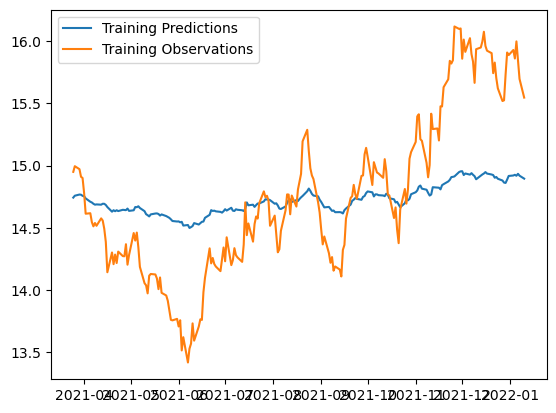

In [21]:
train_predictions = model.predict(X_train).flatten()

plt.plot(dates_train, train_predictions)
plt.plot(dates_train, y_train)
plt.legend(['Training Predictions', 'Training Observations'])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


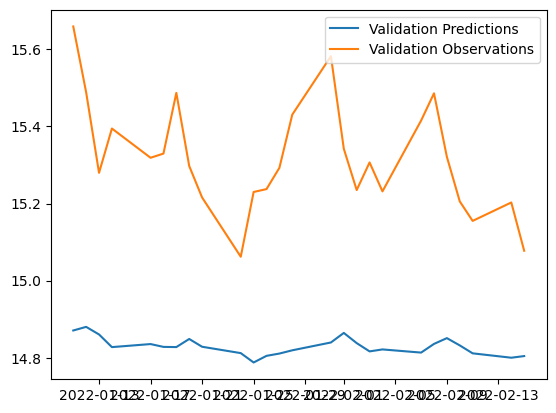

In [22]:
val_predictions = model.predict(X_val).flatten()

plt.plot(dates_val, val_predictions)
plt.plot(dates_val, y_val)
plt.legend(['Validation Predictions', 'Validation Observations'])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


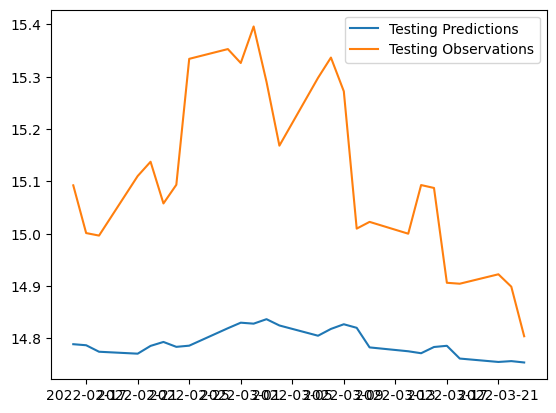

In [23]:
test_predictions = model.predict(X_test).flatten()

plt.plot(dates_test, test_predictions)
plt.plot(dates_test, y_test)
plt.legend(['Testing Predictions', 'Testing Observations'])

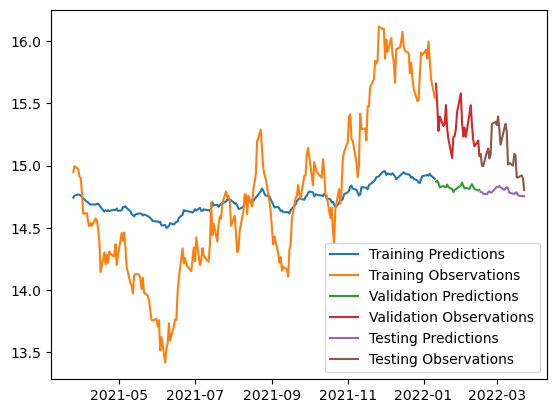

In [24]:
plt.plot(dates_train, train_predictions)
plt.plot(dates_train, y_train)
plt.plot(dates_val, val_predictions)
plt.plot(dates_val, y_val)
plt.plot(dates_test, test_predictions)
plt.plot(dates_test, y_test)
plt.legend(['Training Predictions', 
            'Training Observations',
            'Validation Predictions', 
            'Validation Observations',
            'Testing Predictions', 
            'Testing Observations'])

In [25]:
from copy import deepcopy

recursive_predictions = []
recursive_dates = np.concatenate([dates_val, dates_test])

for target_date in recursive_dates:
  last_window = deepcopy(X_train[-1])
  next_prediction = model.predict(np.array([last_window])).flatten()
  recursive_predictions.append(next_prediction)
  last_window[-1] = next_prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━

In [ ]:
plt.plot(dates_train, train_predictions)
plt.plot(dates_train, y_train)
plt.plot(dates_val, val_predictions)
plt.plot(dates_val, y_val)
plt.plot(dates_test, test_predictions)
plt.plot(dates_test, y_test)
plt.plot(recursive_dates, recursive_predictions)
plt.legend(['Training Predictions', 
            'Training Observations',
            'Validation Predictions', 
            'Validation Observations',
            'Testing Predictions', 
            'Testing Observations',
            'Recursive Predictions'])